<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/proyecto/covid_presentacion_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Influenza, COVID-19 y otros virus respiratorios

**Alumno:** Mario Amador

**Materia:** Analítica Descriptiva y Predictiva

**Profesor:** Dr. Vicente García

**Fecha:** 2026-02-25

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



# 1. Descripción del dataset

## Origen del dataset
El dataset es publicado por la Dirección General de Epidemiología (DGE), perteneciente a la Secretaría de Salud de México, a través de su plataforma de datos abiertos.

Forma parte del Sistema Nacional de Vigilancia Epidemiológica (SINAVE), cuyo objetivo es monitorear la aparición, distribución y evolución de enfermedades en la población.

El conjunto de datos contiene registros reales de casos sospechosos de infecciones respiratorias virales, incluyendo COVID-19, influenza y otros virus.
https://www.gob.mx/salud/acciones-y-programas/direccion-general-de-epidemiologia

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')
pd.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Programación para analítica descriptiva y predictiva/Otros/influenza_covid-19_y_otros_virus_respiratorios/COVID19MEXICO.csv')
df.shape

(177773, 42)

In [83]:
df.head(10)

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,NACIONALIDAD,EMBARAZO,HABLA_LENGUA_INDIG,INDIGENA,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,TOMA_MUESTRA_LAB,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2026-02-03,167f1a,1,12,1,2,1,1,3,1,2025-04-21,2025-04-20,9999-99-99,97,2,8,1,97,2,2,2,2,2,2,2,2,2,2,2,2,2,2,997,997,2,97,6,6,99,México,97,97
1,2026-02-03,gd76fb9,1,8,9,1,9,9,12,1,2025-01-02,2025-01-01,9999-99-99,97,2,69,1,2,2,2,2,2,2,2,2,2,2,1,2,2,2,2,997,997,2,97,6,6,99,México,97,97
2,2026-02-03,g77f0f3,1,4,21,1,21,21,114,1,2025-01-02,2025-01-01,9999-99-99,97,2,40,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,997,997,2,97,6,6,99,México,97,97
3,2026-02-03,g5963e1,1,12,9,1,9,9,13,1,2025-01-02,2025-01-01,9999-99-99,97,2,54,1,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1,5,5,2,97,7,7,99,México,97,97
4,2026-02-03,g88cac9,1,15,21,1,21,21,114,2,2025-01-02,2025-01-02,9999-99-99,1,1,102,1,2,2,2,2,2,1,1,2,2,2,2,2,2,2,1,999,999,2,97,6,6,99,México,97,1
5,2026-02-03,gbbb80b,1,4,20,2,20,20,413,1,2025-01-02,2025-01-01,9999-99-99,97,2,26,1,97,2,2,2,2,2,2,2,2,2,2,2,2,2,2,997,997,2,97,6,6,99,México,97,97
6,2026-02-03,ga47252,1,12,9,1,9,9,13,1,2025-01-02,2025-01-01,9999-99-99,97,2,36,1,2,99,99,2,2,2,2,2,2,2,2,2,2,1,1,5,5,2,97,7,7,99,México,97,97
7,2026-02-03,gd8311d,1,8,9,1,9,9,12,1,2025-01-02,2025-01-01,9999-99-99,97,2,57,1,2,2,2,2,2,2,2,2,1,2,1,2,2,2,2,997,997,2,97,6,6,99,México,97,97
8,2026-02-03,g98e198,1,15,21,1,21,21,114,2,2025-01-02,2025-01-02,9999-99-99,2,2,2,1,2,2,2,2,2,1,1,2,2,2,2,2,2,2,1,3,998,2,97,7,3,99,México,97,2
9,2026-02-03,g5075fe,1,6,9,1,29,9,5,2,2025-01-02,2025-01-01,9999-99-99,2,2,86,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,5,5,2,97,7,7,99,México,97,2


In [84]:
df.columns

Index(['FECHA_ACTUALIZACION', 'ID_REGISTRO', 'ORIGEN', 'SECTOR', 'ENTIDAD_UM',
       'SEXO', 'ENTIDAD_NAC', 'ENTIDAD_RES', 'MUNICIPIO_RES', 'TIPO_PACIENTE',
       'FECHA_INGRESO', 'FECHA_SINTOMAS', 'FECHA_DEF', 'INTUBADO', 'NEUMONIA',
       'EDAD', 'NACIONALIDAD', 'EMBARAZO', 'HABLA_LENGUA_INDIG', 'INDIGENA',
       'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM',
       'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO',
       'OTRO_CASO', 'TOMA_MUESTRA_LAB', 'RESULTADO_PCR',
       'RESULTADO_PCR_COINFECCION', 'TOMA_MUESTRA_ANTIGENO',
       'RESULTADO_ANTIGENO', 'CLASIFICACION_FINAL_COVID',
       'CLASIFICACION_FINAL_FLU', 'MIGRANTE', 'PAIS_NACIONALIDAD',
       'PAIS_ORIGEN', 'UCI'],
      dtype='object')

In [85]:
df.dtypes

,0
FECHA_ACTUALIZACION,object
ID_REGISTRO,object
ORIGEN,int64
SECTOR,int64
ENTIDAD_UM,int64
SEXO,int64
ENTIDAD_NAC,int64
ENTIDAD_RES,int64
MUNICIPIO_RES,int64
TIPO_PACIENTE,int64


## Tipos de variables

### Variables categóricas codificadas (nominales)
ORIGEN  
SECTOR  
ENTIDAD_UM  
SEXO  
ENTIDAD_NAC  
ENTIDAD_RES  
TIPO_PACIENTE  
NACIONALIDAD  
PAIS_NACIONALIDAD  
PAIS_ORIGEN  
RESULTADO_PCR  
RESULTADO_PCR_COINFECCION  
RESULTADO_ANTIGENO  
CLASIFICACION_FINAL_COVID  
CLASIFICACION_FINAL_FLU  
ID_REGISTRO

---

### Variables categóricas de salud (codificadas)
INTUBADO  
NEUMONIA  
EMBARAZO  
HABLA_LENGUA_INDIG  
INDIGENA  
DIABETES  
EPOC  
ASMA  
INMUSUPR  
HIPERTENSION  
OTRA_COM  
CARDIOVASCULAR  
OBESIDAD  
RENAL_CRONICA  
TABAQUISMO  
OTRO_CASO  
TOMA_MUESTRA_LAB  
TOMA_MUESTRA_ANTIGENO  
MIGRANTE  
UCI  

Estas variables representan condiciones de tipo sí/no, pero incluyen valores adicionales como “no especificado”, por lo que no son estrictamente binarias.

---

### Variables numéricas
EDAD (variable cuantitativa discreta)

---

### Variables categóricas geográficas
MUNICIPIO_RES (código geográfico)

---

### Variables temporales
FECHA_ACTUALIZACION  
FECHA_INGRESO  
FECHA_SINTOMAS  
FECHA_DEF

# 2. Revisión de calidad de datos

En esta sección se evalúa la calidad del dataset, identificando posibles problemas que puedan afectar el análisis.

Se revisan los siguientes aspectos:

- Valores faltantes
- Registros duplicados
- Tipos de datos incorrectos
- Consistencia en nombres de columnas

## Valores faltantes

Se identifican valores nulos en el dataset para determinar si es necesario aplicar técnicas de imputación o eliminación.

In [86]:
# Valores nulos por columna
df.isnull().sum()

,0
FECHA_ACTUALIZACION,0
ID_REGISTRO,0
ORIGEN,0
SECTOR,0
ENTIDAD_UM,0
SEXO,0
ENTIDAD_NAC,0
ENTIDAD_RES,0
MUNICIPIO_RES,0
TIPO_PACIENTE,0


## Registros duplicados

Se verifica si existen registros duplicados que puedan sesgar el análisis.

In [87]:
# Registros duplicados
df.duplicated().sum()

np.int64(0)

# 3. Preprocesamiento de datos

En esta sección se realizan transformaciones sobre el dataset con el objetivo de mejorar su calidad y prepararlo para el análisis exploratorio.


## Transformación de variables categóricas

Se realizó la conversión de variables codificadas a valores descriptivos utilizando los catálogos oficiales proporcionados.

Esto permitió reemplazar valores numéricos por etiquetas interpretables, mejorando la comprensión de los datos y facilitando su análisis.

Las transformaciones incluyen:

- Variables demográficas (sexo, nacionalidad)
- Variables clínicas (comorbilidades)
- Variables de resultados (PCR, antígeno, clasificación)
- Variables geográficas (entidad federativa)

In [88]:
df_original = df.copy()
df_clean = df.copy()

In [89]:
ruta_catalogo = '/content/drive/MyDrive/Colab Notebooks/Programación para analítica descriptiva y predictiva/Otros/influenza_covid-19_y_otros_virus_respiratorios/240708 Catalogos.xlsx'

catalogos = pd.read_excel(ruta_catalogo, sheet_name=None)

In [90]:
catalogos['Catálogo SEXO'].dtypes

,0
CLAVE,int64
DESCRIPCIÓN,object


In [91]:
def crear_mapeo(df_catalogo, clave='CLAVE', valor='DESCRIPCIÓN'):
    return dict(zip(df_catalogo[clave], df_catalogo[valor]))

In [92]:
# mapear las columnas
mapeos = {
    'ORIGEN': 'Catálogo ORIGEN',
    'SECTOR': 'Catálogo SECTOR',
    'SEXO': 'Catálogo SEXO',
    'TIPO_PACIENTE': 'Catálogo TIPO_PACIENTE',
    'NACIONALIDAD': 'Catálogo NACIONALIDAD',
    'RESULTADO_PCR': 'Catálogo RESULTADO_PCR',
    'RESULTADO_ANTIGENO': 'Catálogo RESULTADO_ANTIGENO'
}

for col, hoja in mapeos.items():
    mapeo = crear_mapeo(catalogos[hoja])
    df_clean[col] = df_clean[col].map(mapeo)

In [93]:
# columnas con variables si / no
mapeo_si_no = crear_mapeo(catalogos['Catálogo SI_NO'])

columnas_si_no = [
    'INTUBADO','NEUMONIA','EMBARAZO','HABLA_LENGUA_INDIG','INDIGENA',
    'DIABETES','EPOC','ASMA','INMUSUPR','HIPERTENSION','OTRA_COM',
    'CARDIOVASCULAR','OBESIDAD','RENAL_CRONICA','TABAQUISMO','OTRO_CASO',
    'TOMA_MUESTRA_LAB','TOMA_MUESTRA_ANTIGENO','MIGRANTE','UCI'
]

for col in columnas_si_no:
    df_clean[col] = df_clean[col].map(mapeo_si_no)

In [94]:
# covid / flu
mapeo_covid = crear_mapeo(
    catalogos['Cat CLASIFICACION_FINAL_COVID'],
    clave='CLAVE',
    valor='CLASIFICACIÓN'
)

df_clean['CLASIFICACION_FINAL_COVID'] = df_clean['CLASIFICACION_FINAL_COVID'].map(mapeo_covid)


mapeo_flu = crear_mapeo(
    catalogos['Cat CLASIFICACION_FINAL_FLU'],
    clave='CLAVE',
    valor='CLASIFICACIÓN'
)

df_clean['CLASIFICACION_FINAL_FLU'] = df_clean['CLASIFICACION_FINAL_FLU'].map(mapeo_flu)

In [95]:
# Entidades
mapeo_entidad = crear_mapeo(
    catalogos['Catálogo de ENTIDADES'],
    clave='CLAVE_ENTIDAD',
    valor='ENTIDAD_FEDERATIVA'
)

for col in ['ENTIDAD_UM', 'ENTIDAD_NAC', 'ENTIDAD_RES']:
    df_clean[col] = df_clean[col].map(mapeo_entidad)

In [96]:
# Resultado PCR
mapeo_coinf = crear_mapeo(catalogos['Catálogo RESULTADO_PCR'])

df_clean['RESULTADO_PCR_COINFECCION'] = df_clean['RESULTADO_PCR_COINFECCION'].map(mapeo_coinf)

In [97]:
df_clean.isna().sum().sort_values(ascending=False)

,0
FECHA_ACTUALIZACION,0
ID_REGISTRO,0
ORIGEN,0
SECTOR,0
ENTIDAD_UM,0
SEXO,0
ENTIDAD_NAC,0
ENTIDAD_RES,0
MUNICIPIO_RES,0
TIPO_PACIENTE,0


### Notas
- No se hizo la conversión de MUNICIPIO_RES ya que es mucho y se tienen que convinar las claves de la entidad con el municipio, así que se dejará para después

In [98]:
df_clean.head(5)

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,NACIONALIDAD,EMBARAZO,HABLA_LENGUA_INDIG,INDIGENA,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,TOMA_MUESTRA_LAB,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2026-02-03,167f1a,USMER,SSA,AGUASCALIENTES,HOMBRE,AGUASCALIENTES,AGUASCALIENTES,3,AMBULATORIO,2025-04-21,2025-04-20,9999-99-99,NO APLICA,NO,8,MEXICANA,NO APLICA,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO APLICA (CASO SIN MUESTRA),NO APLICA (CASO SIN MUESTRA),NO,NO APLICA (CASO SIN MUESTRA),CASO SOSPECHOSO,CASO SOSPECHOSO,NO ESPECIFICADO,México,97,NO APLICA
1,2026-02-03,gd76fb9,USMER,PEMEX,CIUDAD DE MÉXICO,MUJER,CIUDAD DE MÉXICO,CIUDAD DE MÉXICO,12,AMBULATORIO,2025-01-02,2025-01-01,9999-99-99,NO APLICA,NO,69,MEXICANA,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO APLICA (CASO SIN MUESTRA),NO APLICA (CASO SIN MUESTRA),NO,NO APLICA (CASO SIN MUESTRA),CASO SOSPECHOSO,CASO SOSPECHOSO,NO ESPECIFICADO,México,97,NO APLICA
2,2026-02-03,g77f0f3,USMER,IMSS,PUEBLA,MUJER,PUEBLA,PUEBLA,114,AMBULATORIO,2025-01-02,2025-01-01,9999-99-99,NO APLICA,NO,40,MEXICANA,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO APLICA (CASO SIN MUESTRA),NO APLICA (CASO SIN MUESTRA),NO,NO APLICA (CASO SIN MUESTRA),CASO SOSPECHOSO,CASO SOSPECHOSO,NO ESPECIFICADO,México,97,NO APLICA
3,2026-02-03,g5963e1,USMER,SSA,CIUDAD DE MÉXICO,MUJER,CIUDAD DE MÉXICO,CIUDAD DE MÉXICO,13,AMBULATORIO,2025-01-02,2025-01-01,9999-99-99,NO APLICA,NO,54,MEXICANA,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,SI,NEGATIVO,NEGATIVO,NO,NO APLICA (CASO SIN MUESTRA),NEGATIVO A SARS-COV-2,NEGATIVO A INFLUENZA,NO ESPECIFICADO,México,97,NO APLICA
4,2026-02-03,g88cac9,USMER,IMSS Bienestar OPD,PUEBLA,MUJER,PUEBLA,PUEBLA,114,HOSPITALIZADO,2025-01-02,2025-01-02,9999-99-99,SI,SI,102,MEXICANA,NO,NO,NO,NO,NO,SI,SI,NO,NO,NO,NO,NO,NO,NO,SI,PENDIENTE,PENDIENTE,NO,NO APLICA (CASO SIN MUESTRA),CASO SOSPECHOSO,CASO SOSPECHOSO,NO ESPECIFICADO,México,97,SI


In [99]:
df_clean.shape

(177773, 42)

## Preparación de variables para análisis

Se realizaron ajustes adicionales en variables categóricas para asegurar consistencia en su formato.

Por ejemplo:

- Normalización de texto en variables como país de origen
- Sustitución de valores codificados por etiquetas descriptivas

In [100]:
# PAIS_ORIGEN venía como objeto, pero sí hay se encuentra un único valor códificado
df_clean['PAIS_ORIGEN'].unique()[:10]

array(['97', 'Venezuela', 'Estados Unidos de América', 'Perú',
       'República de Honduras', 'Otro', 'Alemania', 'Guatemala',
       'Nicaragua', 'El Salvador'], dtype=object)

In [101]:
# Como nota, en los catálogos solo venía el 99 (NO ESPECIFICADO) pero en realidad es el 97
df_clean['PAIS_ORIGEN'] = df_clean['PAIS_ORIGEN'].replace('97', 'NO ESPECIFICADO')

In [102]:
df_clean['PAIS_ORIGEN'].unique()[:10]

array(['NO ESPECIFICADO', 'Venezuela', 'Estados Unidos de América',
       'Perú', 'República de Honduras', 'Otro', 'Alemania', 'Guatemala',
       'Nicaragua', 'El Salvador'], dtype=object)

In [103]:
# Normalizar
df_clean['PAIS_ORIGEN'] = df_clean['PAIS_ORIGEN'].str.strip().str.upper()

In [104]:
df_clean['PAIS_ORIGEN'].unique()[:10]

array(['NO ESPECIFICADO', 'VENEZUELA', 'ESTADOS UNIDOS DE AMÉRICA',
       'PERÚ', 'REPÚBLICA DE HONDURAS', 'OTRO', 'ALEMANIA', 'GUATEMALA',
       'NICARAGUA', 'EL SALVADOR'], dtype=object)

## Transformación de variables temporales

Se identificaron variables de fecha almacenadas como tipo `object`, por lo que se realizó su conversión a tipo datetime.

Durante este proceso, valores no válidos como "9999-99-99" fueron transformados a valores nulos (`NaT`).

Es importante destacar que, en variables como `FECHA_DEF`, los valores nulos no representan un error, sino la ausencia de defunción del paciente.

In [105]:
# Columnas de fecha
columnas_fechas = [
    'FECHA_ACTUALIZACION',
    'FECHA_INGRESO',
    'FECHA_SINTOMAS',
    'FECHA_DEF'
]

# Conversión a datetime
for col in columnas_fechas:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Verificar tipos de datos
df_clean[columnas_fechas].dtypes

/tmp/ipykernel_874/522944083.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')


,0
FECHA_ACTUALIZACION,datetime64[ns]
FECHA_INGRESO,datetime64[ns]
FECHA_SINTOMAS,datetime64[ns]
FECHA_DEF,datetime64[ns]


In [106]:
# Ver primeras filas para validar formato
df_clean[columnas_fechas].head()

,FECHA_ACTUALIZACION,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF
0,2026-02-03,2025-04-21,2025-04-20,NaT
1,2026-02-03,2025-01-02,2025-01-01,NaT
2,2026-02-03,2025-01-02,2025-01-01,NaT
3,2026-02-03,2025-01-02,2025-01-01,NaT
4,2026-02-03,2025-01-02,2025-01-02,NaT


In [107]:
# Backup
df_clean.to_csv('/content/drive/MyDrive/df_clean.csv', index=False)

# 4. Análisis univariado

## Variable: EDAD

Se analiza la distribución de la variable `EDAD`, la cual representa la edad de los pacientes registrados en el dataset.

Al ser una variable numérica, se utilizan medidas de estadística descriptiva y visualizaciones para comprender su comportamiento.

### Justificación de la variable analizada

El análisis de valores atípicos se realizó sobre la variable `EDAD`, ya que es la única variable numérica continua en el dataset.

In [108]:
# calcular cuartiles
Q1 = df_clean['EDAD'].quantile(0.25)
Q3 = df_clean['EDAD'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

Q1, Q3, IQR, limite_inferior, limite_superior

(np.float64(11.0),
 np.float64(56.0),
 np.float64(45.0),
 np.float64(-56.5),
 np.float64(123.5))

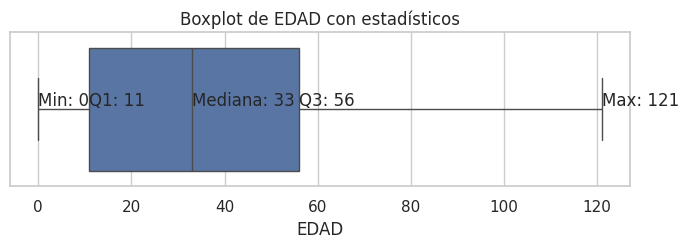

In [109]:
# calcular estadísticas
desc = df_clean['EDAD'].describe()

plt.figure(figsize=(8,2))
sns.boxplot(x=df_clean['EDAD'])

# agregar anotaciones
plt.text(desc['min'], 0, f"Min: {desc['min']:.0f}", verticalalignment='bottom')
plt.text(desc['25%'], 0, f"Q1: {desc['25%']:.0f}", verticalalignment='bottom')
plt.text(desc['50%'], 0, f"Mediana: {desc['50%']:.0f}", verticalalignment='bottom')
plt.text(desc['75%'], 0, f"Q3: {desc['75%']:.0f}", verticalalignment='bottom')
plt.text(desc['max'], 0, f"Max: {desc['max']:.0f}", verticalalignment='bottom')

plt.title("Boxplot de EDAD con estadísticos")
plt.yticks([])
plt.show()

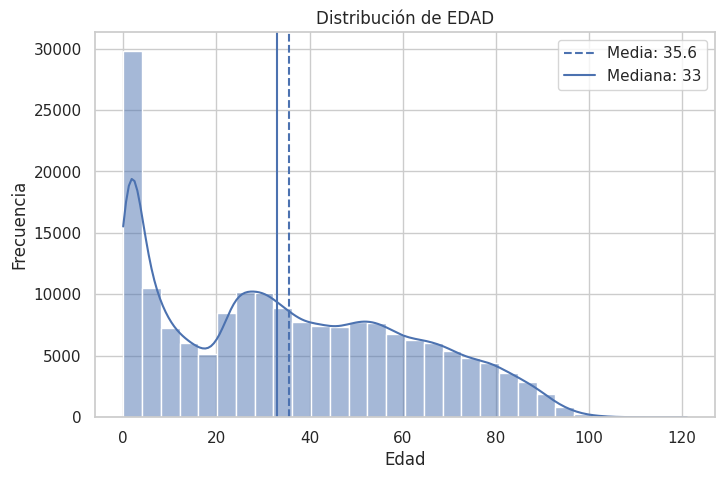

In [110]:

desc = df_clean['EDAD'].describe()
mean = desc['mean']
median = desc['50%']

plt.figure(figsize=(8,5))

# histograma + KDE
sns.histplot(df_clean['EDAD'], bins=30, kde=True)

# líneas de referencia
plt.axvline(mean, linestyle='--', label=f"Media: {mean:.1f}")
plt.axvline(median, linestyle='-', label=f"Mediana: {median:.0f}")

plt.title("Distribución de EDAD")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.legend()
plt.show()

### Resultados del análisis

La variable `EDAD` presenta las siguientes características:

- Media: 35.6 años  
- Mediana: 33 años  
- Rango: 0 a 121 años  

Se observa una distribución amplia que incluye desde recién nacidos hasta adultos mayores.

## Variable: SEXO

Al tratarse de una variable categórica, se utiliza un conteo de frecuencias y una visualización de tipo gráfico de barras.

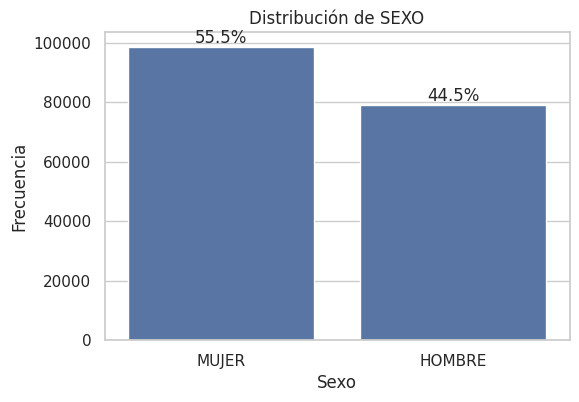

In [111]:
# conteo y porcentaje
counts = df_clean['SEXO'].value_counts()
percent = df_clean['SEXO'].value_counts(normalize=True) * 100

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
ax = sns.barplot(x=counts.index, y=counts.values)

# etiquetas con porcentaje
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{percent.iloc[i]:.1f}%", ha='center', va='bottom')

plt.title("Distribución de SEXO")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")

plt.show()

### Resultados del análisis

La distribución de la variable `SEXO` es la siguiente:

- MUJER: 55.47%  
- HOMBRE: 44.53%  

Se observa una mayor proporción de mujeres en el dataset.

## Variable: RESULTADO_PCR

Se analiza la variable `RESULTADO_PCR`, la cual representa el resultado de pruebas de laboratorio para la detección de distintos virus respiratorios.

Al tratarse de una variable categórica con múltiples niveles, se analizan las frecuencias de las categorías más relevantes.

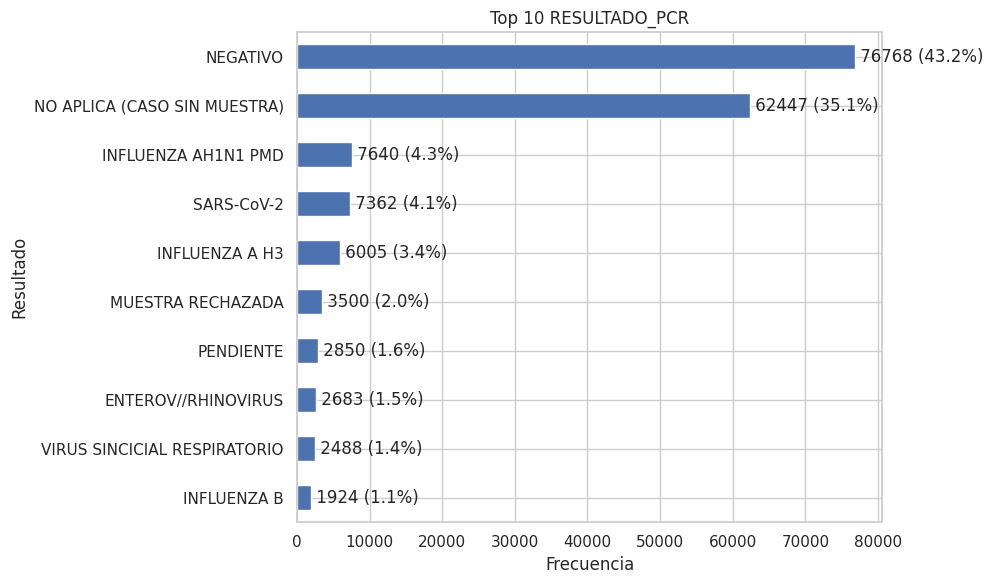

In [112]:
# Top 10
top_pcr = df_clean['RESULTADO_PCR'].value_counts().head(10)

# porcentaje sobre el total del dataset
percent = (top_pcr / len(df_clean)) * 100

# ordenar para barh
top_pcr = top_pcr.sort_values()
percent = percent.loc[top_pcr.index]

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
ax = top_pcr.plot(kind='barh')

# etiquetas: conteo + %
for i, (count, pct) in enumerate(zip(top_pcr.values, percent.values)):
    plt.text(count, i, f" {count} ({pct:.1f}%)", va='center')

plt.title("Top 10 RESULTADO_PCR")
plt.xlabel("Frecuencia")
plt.ylabel("Resultado")

plt.tight_layout()
plt.show()

### Resultados del análisis

Las categorías más frecuentes de la variable `RESULTADO_PCR` son:

- NEGATIVO: 43.18%  
- NO APLICA (CASO SIN MUESTRA): 35.13%  
- SARS-CoV-2: 4.14%  
- Influenza y otros virus respiratorios: proporciones menores

## Variable: DIABETES

Se analiza la variable `DIABETES`, la cual indica si el paciente presenta esta comorbilidad.

Al tratarse de una variable categórica, se evalúa mediante conteo de frecuencias y visualización de barras.

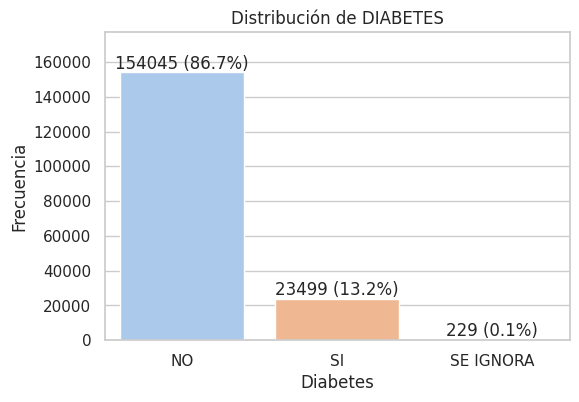

In [113]:
# conteos y porcentajes
df_clean['DIABETES'] = df_clean['DIABETES'].str.strip()


counts = df_clean['DIABETES'].value_counts()
percent = (counts / counts.sum()) * 100

order = ['NO', 'SI', 'SE IGNORA']
counts = counts.reindex(order)
percent = percent.reindex(order)

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
plt.xticks(rotation=0)
# ax = sns.barplot(x=counts.index, y=counts.values, palette="pastel")
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="pastel",
    legend=False
)

# etiquetas: conteo + %
for i, (count, pct) in enumerate(zip(counts.values, percent.values)):
    plt.text(i, count, f"{count} ({pct:.1f}%)", ha='center', va='bottom')

plt.title("Distribución de DIABETES")
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")

# un poco de espacio arriba para las etiquetas
plt.ylim(0, counts.max() * 1.15)

plt.show()

### Resultados del análisis

La distribución de la variable `DIABETES` es la siguiente:

- NO: 86.65%  
- SI: 13.22%  
- SE IGNORA: 0.13%  

La mayoría de los pacientes no presenta diabetes, aunque existe una proporción relevante de casos con esta condición.

## Variable: HIPERTENSION

Se analiza la variable `HIPERTENSION`, la cual indica si el paciente presenta esta comorbilidad.

Al tratarse de una variable categórica, se evalúa mediante conteo de frecuencias y visualización de barras.

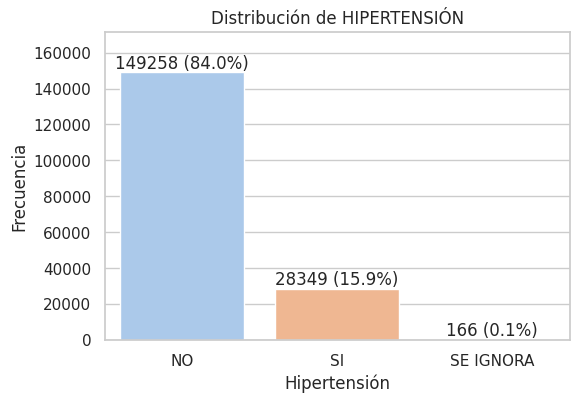

In [114]:
# limpiar por si acaso
df_clean['HIPERTENSION'] = df_clean['HIPERTENSION'].str.strip()

# conteos y porcentajes
counts = df_clean['HIPERTENSION'].value_counts()
percent = (counts / counts.sum()) * 100

# orden lógico
order = ['NO', 'SI', 'SE IGNORA']
counts = counts.loc[[c for c in order if c in counts.index]]
percent = percent.loc[counts.index]

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="pastel",
    legend=False
)

# etiquetas
for i, (count, pct) in enumerate(zip(counts.values, percent.values)):
    plt.text(i, count, f"{count} ({pct:.1f}%)", ha='center', va='bottom')

plt.title("Distribución de HIPERTENSIÓN")
plt.xlabel("Hipertensión")
plt.ylabel("Frecuencia")

plt.ylim(0, counts.max() * 1.15)

plt.show()

### Resultados del análisis

La distribución de la variable `HIPERTENSION` es la siguiente:

- NO: 83.96%  
- SI: 15.95%  
- SE IGNORA: 0.09%  

Se observa que la mayoría de los pacientes no presenta hipertensión, aunque existe una proporción relevante con esta condición.1

# 5. Análisis bivariado

## Relación entre EDAD y FALLECIO

Se analiza la relación entre la edad de los pacientes y su desenlace (fallecimiento), con el objetivo de identificar si existe un patrón entre la edad y la probabilidad de fallecer.

Para ello, se utilizan visualizaciones y agrupaciones que permiten comparar ambos grupos.

In [115]:
df_clean['FALLECIO'] = df_clean['FECHA_DEF'].notna()

/tmp/ipykernel_874/3129954416.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


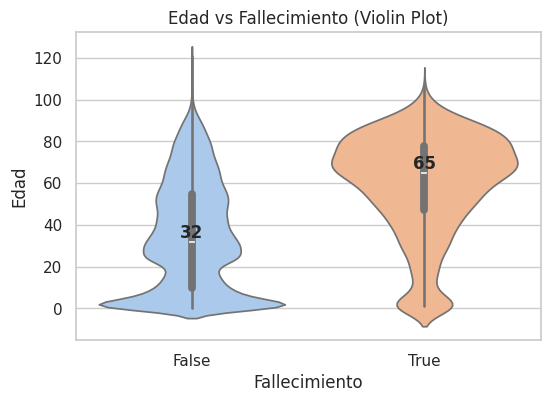

In [116]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

# violin plot
ax = sns.violinplot(
    x='FALLECIO',
    y='EDAD',
    data=df_clean,
    inner='box',   # muestra boxplot dentro
    palette='pastel',
    legend=False
)

# calcular medianas
medians = df_clean.groupby('FALLECIO')['EDAD'].median()

# agregar etiquetas de mediana
for i, med in enumerate(medians):
    plt.text(i, med, f"{med:.0f}", ha='center', va='bottom', fontweight='bold')

plt.title("Edad vs Fallecimiento (Violin Plot)")
plt.xlabel("Fallecimiento")
plt.ylabel("Edad")

plt.show()

### Resultados del análisis

Se comparó la edad de los pacientes en función de su desenlace:

- Promedio de edad (no falleció): 34.7 años  
- Promedio de edad (falleció): 59.35 años  

- Mediana (no falleció): 32 años  
- Mediana (falleció): 65 años  

Se observa una diferencia significativa en la edad entre ambos grupos.

## Relación entre DIABETES y FALLECIO

Se analiza la relación entre la presencia de diabetes y el desenlace del paciente, con el objetivo de identificar si esta comorbilidad está asociada con una mayor proporción de fallecimientos.

In [117]:
pd.crosstab(df_clean['DIABETES'], df_clean['FALLECIO'])

FALLECIO,False,True
DIABETES,,
NO,149911,4134
SE IGNORA,205,24
SI,21349,2150


In [118]:
pd.crosstab(df_clean['DIABETES'], df_clean['FALLECIO'], normalize='index') * 100

FALLECIO,False,True
DIABETES,,
NO,97.316369,2.683631
SE IGNORA,89.519651,10.480349
SI,90.850674,9.149326


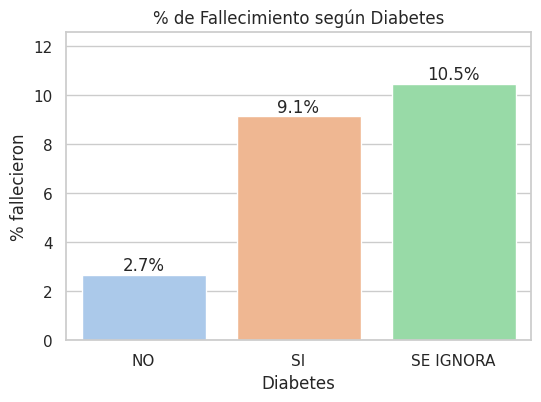

In [119]:

df_clean['DIABETES'] = df_clean['DIABETES'].str.strip()

tabla = pd.crosstab(
    df_clean['DIABETES'],
    df_clean['FALLECIO'],
    normalize='index'
) * 100

fallecidos = tabla[True]

order = ['NO', 'SI', 'SE IGNORA']
fallecidos = fallecidos.loc[[c for c in order if c in fallecidos.index]]

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=fallecidos.index,
    y=fallecidos.values,
    hue=fallecidos.index,
    palette="pastel",
    legend=False
)

for i, val in enumerate(fallecidos.values):
    plt.text(i, val, f"{val:.1f}%", ha='center', va='bottom')

plt.title("% de Fallecimiento según Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("% fallecieron")

plt.ylim(0, fallecidos.max() * 1.2)

plt.show()

### Resultados del análisis

Se comparó la proporción de fallecimiento en función de la presencia de diabetes:

- Pacientes sin diabetes: 2.68% fallecieron  
- Pacientes con diabetes: 9.15% fallecieron  

Se observa una diferencia significativa entre ambos grupos.

## Relación entre HIPERTENSION y FALLECIO

Se analiza la relación entre la presencia de hipertensión y el desenlace del paciente, con el objetivo de identificar si esta comorbilidad está asociada con una mayor proporción de fallecimientos.

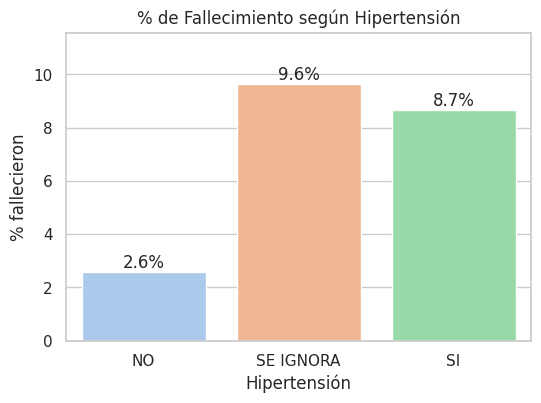

In [120]:
# tabla de proporciones
tabla = pd.crosstab(
    df_clean['HIPERTENSION'],
    df_clean['FALLECIO'],
    normalize='index'
) * 100

# nos quedamos solo con los que fallecieron (True)
fallecidos = tabla[True]

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=fallecidos.index,
    y=fallecidos.values,
    hue=fallecidos.index,
    palette="pastel",
    legend=False
)

# etiquetas
for i, val in enumerate(fallecidos.values):
    plt.text(i, val, f"{val:.1f}%", ha='center', va='bottom')

plt.title("% de Fallecimiento según Hipertensión")
plt.xlabel("Hipertensión")
plt.ylabel("% fallecieron")

plt.ylim(0, fallecidos.max() * 1.2)

plt.show()

### Resultados del análisis

Se comparó la proporción de fallecimiento en función de la presencia de hipertensión:

- Pacientes sin hipertensión: ~2.57% fallecieron  
- Pacientes con hipertensión: ~8.67% fallecieron  

Se observa una diferencia significativa entre ambos grupos.


### Relación entre EDAD y días desde inicio de síntomas hasta ingreso

Se analizó la relación entre la edad de los pacientes y el tiempo transcurrido desde el inicio de síntomas hasta su ingreso al sistema de salud.


In [126]:
df_clean['DIAS_SINTOMAS_INGRESO'] = (df_clean['FECHA_INGRESO'] - df_clean['FECHA_SINTOMAS']).dt.days

In [127]:
df_temp = df_clean[df_clean['DIAS_SINTOMAS_INGRESO'] < 60]

## Relación entre tiempo de ingreso y fallecimiento

Se analiza la relación entre el tiempo transcurrido desde el inicio de síntomas hasta el ingreso al sistema de salud y el desenlace del paciente.

El objetivo es identificar si el tiempo de atención está asociado con una mayor probabilidad de fallecimiento.

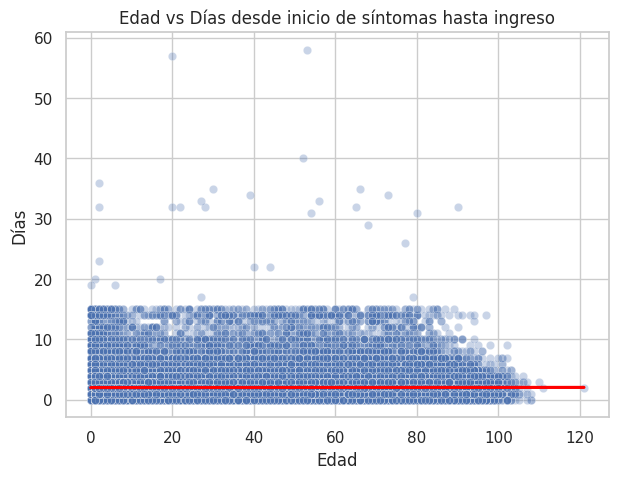

In [136]:
sns.set(style="whitegrid")

plt.figure(figsize=(7,5))

# scatter
sns.scatterplot(
    x='EDAD',
    y='DIAS_SINTOMAS_INGRESO',
    data=df_temp,
    alpha=0.3
)

# línea de tendencia
sns.regplot(
    x='EDAD',
    y='DIAS_SINTOMAS_INGRESO',
    data=df_temp,
    scatter=False,
    color='red'
)

plt.title("Edad vs Días desde inicio de síntomas hasta ingreso")
plt.xlabel("Edad")
plt.ylabel("Días")

plt.show()

## Tiempo (mes) vs Fallecimiento

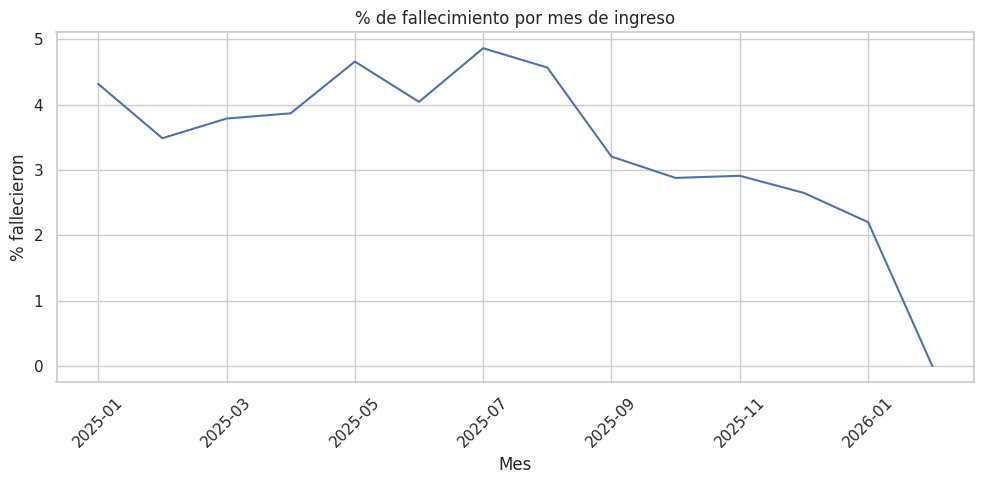

In [141]:
# Crear mes de ingreso
df_clean['MES_INGRESO'] = df_clean['FECHA_INGRESO'].dt.to_period('M').astype(str)

# Proporción de fallecidos por mes
tabla_mes = pd.crosstab(
    df_clean['MES_INGRESO'],
    df_clean['FALLECIO'],
    normalize='index'
) * 100

# Tomar solo % de fallecidos
fallecidos_mes = tabla_mes[True]

plt.figure(figsize=(10,5))
fallecidos_mes.plot()
plt.title("% de fallecimiento por mes de ingreso")
plt.xlabel("Mes")
plt.ylabel("% fallecieron")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Casos por mes

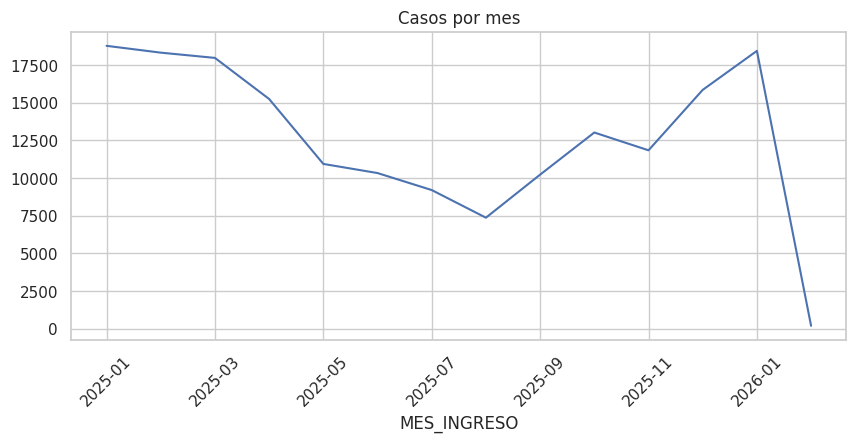

In [133]:
df_clean['MES_INGRESO'].value_counts().sort_index().plot(figsize=(10,4))
plt.title("Casos por mes")
plt.xticks(rotation=45)
plt.show()

## Casos positivos por mes

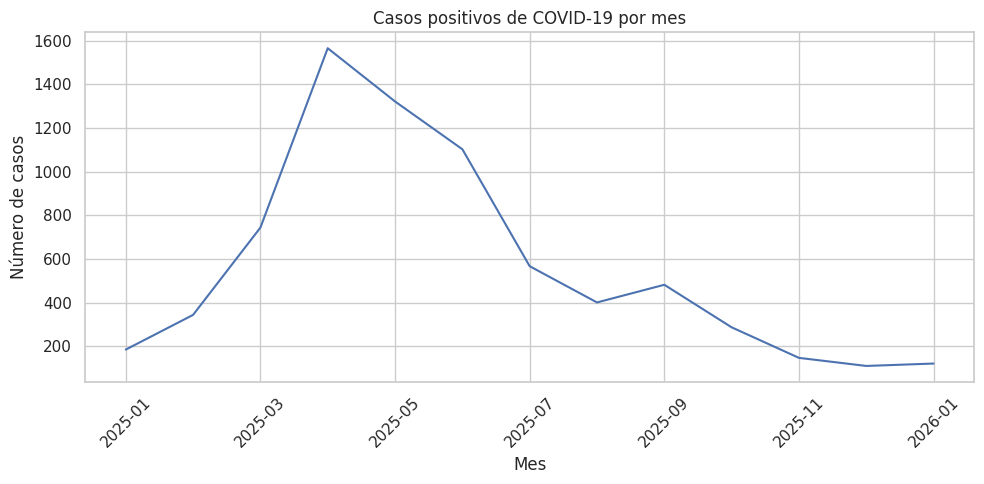

In [134]:
# Filtrar casos positivos
df_positivos = df_clean[
    df_clean['CLASIFICACION_FINAL_COVID'] == 'CASO DE SARS-COV-2  CONFIRMADO'
]

# Contar por mes
positivos_por_mes = df_positivos['MES_INGRESO'].value_counts().sort_index()

plt.figure(figsize=(10,5))
positivos_por_mes.plot()

plt.title("Casos positivos de COVID-19 por mes")
plt.xlabel("Mes")
plt.ylabel("Número de casos")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
total_por_mes = df_clean['MES_INGRESO'].value_counts().sort_index()

proporcion = (positivos_por_mes / total_por_mes) * 100

plt.figure(figsize=(10,5))
proporcion.plot()

plt.title("% de casos positivos por mes")
plt.ylabel("% positivos")
plt.xticks(rotation=45)

plt.show()

# 6. Análisis multivariado

## Matriz de correlación

En esta sección se analizan las relaciones entre múltiples variables de forma simultánea mediante una matriz de correlación.

A diferencia del análisis bivariado, que evalúa pares de variables de manera individual, la matriz de correlación permite observar de manera global cómo se relacionan las variables entre sí.

Para este análisis se seleccionaron variables numéricas relevantes, incluyendo edad, desenlace del paciente y variables temporales derivadas, con el fin de identificar patrones generales en el comportamiento de los datos.

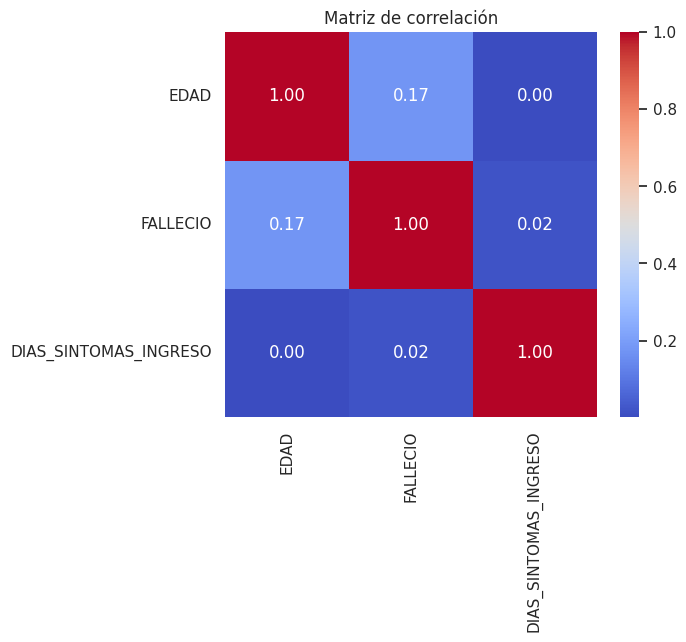

In [135]:
# Variables para correlacionar

df_corr = df_clean[
    ['EDAD', 'FALLECIO', 'DIAS_SINTOMAS_INGRESO']
].copy()

# Convertir
df_corr['FALLECIO'] = df_corr['FALLECIO'].astype(int)

# Eliminar valores negativos (si existen)
df_corr = df_corr[df_corr['DIAS_SINTOMAS_INGRESO'] >= 0]

# Eliminar nulos
df_corr = df_corr.dropna()

plt.figure(figsize=(6,5))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de correlación")
plt.show()

### Interpretación

La matriz de correlación muestra que la edad presenta una relación positiva con el fallecimiento, lo cual coincide con los resultados del análisis bivariado.

Por otro lado, el tiempo desde el inicio de síntomas hasta el ingreso no muestra una relación significativa con el desenlace.

Asimismo, no se observa relación entre la edad y el tiempo de ingreso, lo que indica que estas variables son independientes.

---

### Conclusión

Los resultados confirman que la edad es el factor más relevante en el desenlace del paciente, mientras que el tiempo de atención no presenta una influencia significativa.

# Conclusiones generales

El análisis exploratorio de datos permitió identificar patrones relevantes en el comportamiento del dataset de vigilancia epidemiológica.

Se encontró que la edad es el factor más influyente en el desenlace del paciente, ya que las personas que fallecen presentan edades considerablemente mayores en comparación con quienes no fallecen.

Asimismo, la presencia de comorbilidades como diabetes e hipertensión se asocia con una mayor proporción de fallecimiento, lo que indica que estas condiciones representan factores de riesgo importantes.

Por otro lado, el tiempo transcurrido desde el inicio de síntomas hasta el ingreso al sistema de salud no mostró una relación significativa con el desenlace, lo que sugiere que este factor no es determinante dentro del conjunto de datos analizado.

El análisis temporal permitió observar variaciones en los casos positivos a lo largo del tiempo, evidenciando cambios en la dinámica de la enfermedad.

En conjunto, estos resultados permiten comprender mejor los factores asociados al comportamiento del dataset y sientan las bases para futuros análisis predictivos.